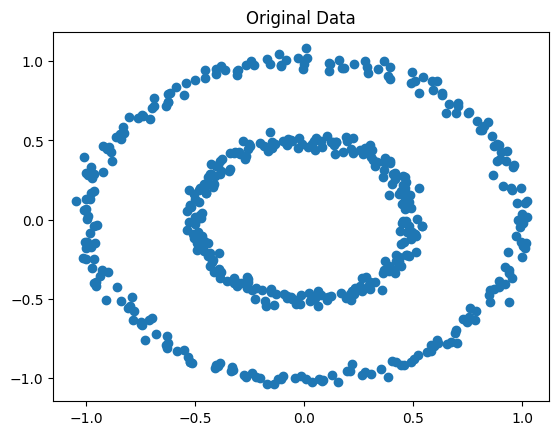

In [1]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.03,
    random_state=10
)

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()

## Kmeans

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


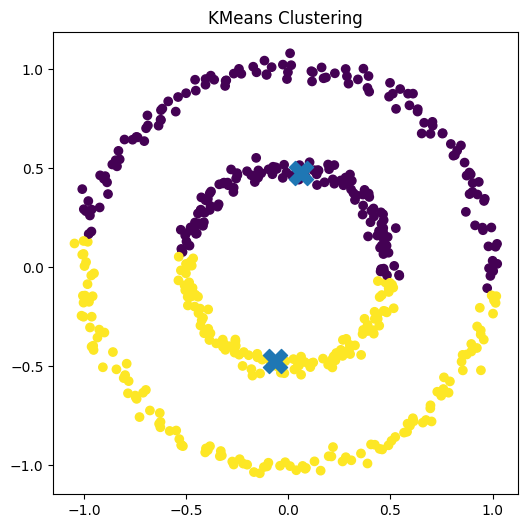

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

labels = kmeans.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.title("KMeans Clustering")
plt.show()

#### KMeans thinks:Cluster = Around a centroid
- KMeans cuts the circles into slices
- instead of identifying inner and outer circles.

## Hierarchical Clustering
- Use Ward linkage because this is the default commonly taught approach

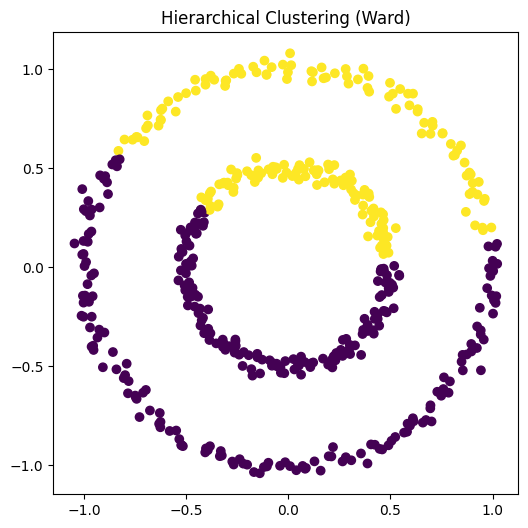

In [3]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

labels = hc.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='viridis'
)

plt.title("Hierarchical Clustering (Ward)")
plt.show()

Ward linkage tries to:

Minimize within-cluster variance

## DBSCAN

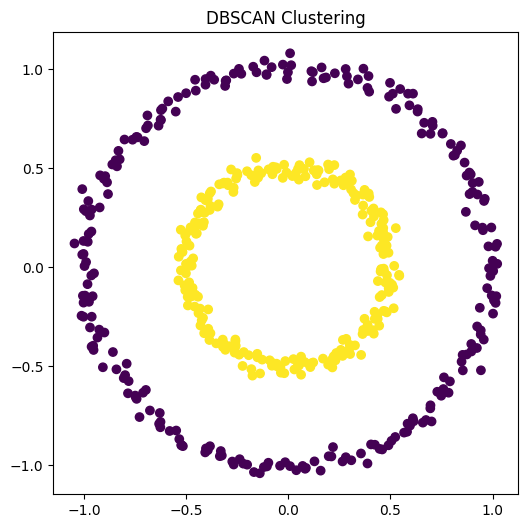

In [4]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan = DBSCAN(
    eps=0.15,
    min_samples=5
)

labels = dbscan.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='viridis'
)

plt.title("DBSCAN Clustering")
plt.show()

DBSCAN does NOT look for:Centroids

Instead it asks:

    - Which points are densely connected?

Therefore:

    - Inner Circle = Cluster 1

    - Outer Circle = Cluster 2

Perfect clustering.

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


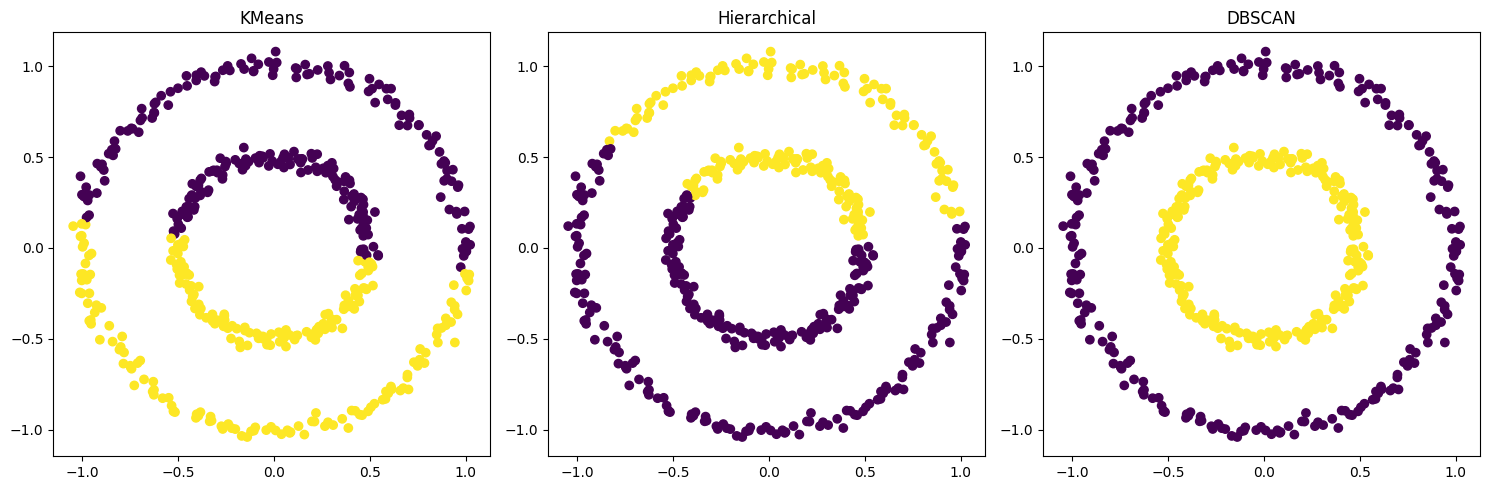

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.03,
    random_state=10
)

kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(X)

hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)
hc_labels = hc.fit_predict(X)

dbscan = DBSCAN(
    eps=0.15,
    min_samples=5
)
db_labels = dbscan.fit_predict(X)

fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].scatter(X[:,0],X[:,1],c=km_labels,cmap='viridis')
ax[0].set_title("KMeans")

ax[1].scatter(X[:,0],X[:,1],c=hc_labels,cmap='viridis')
ax[1].set_title("Hierarchical")

ax[2].scatter(X[:,0],X[:,1],c=db_labels,cmap='viridis')
ax[2].set_title("DBSCAN")

plt.tight_layout()
plt.show()